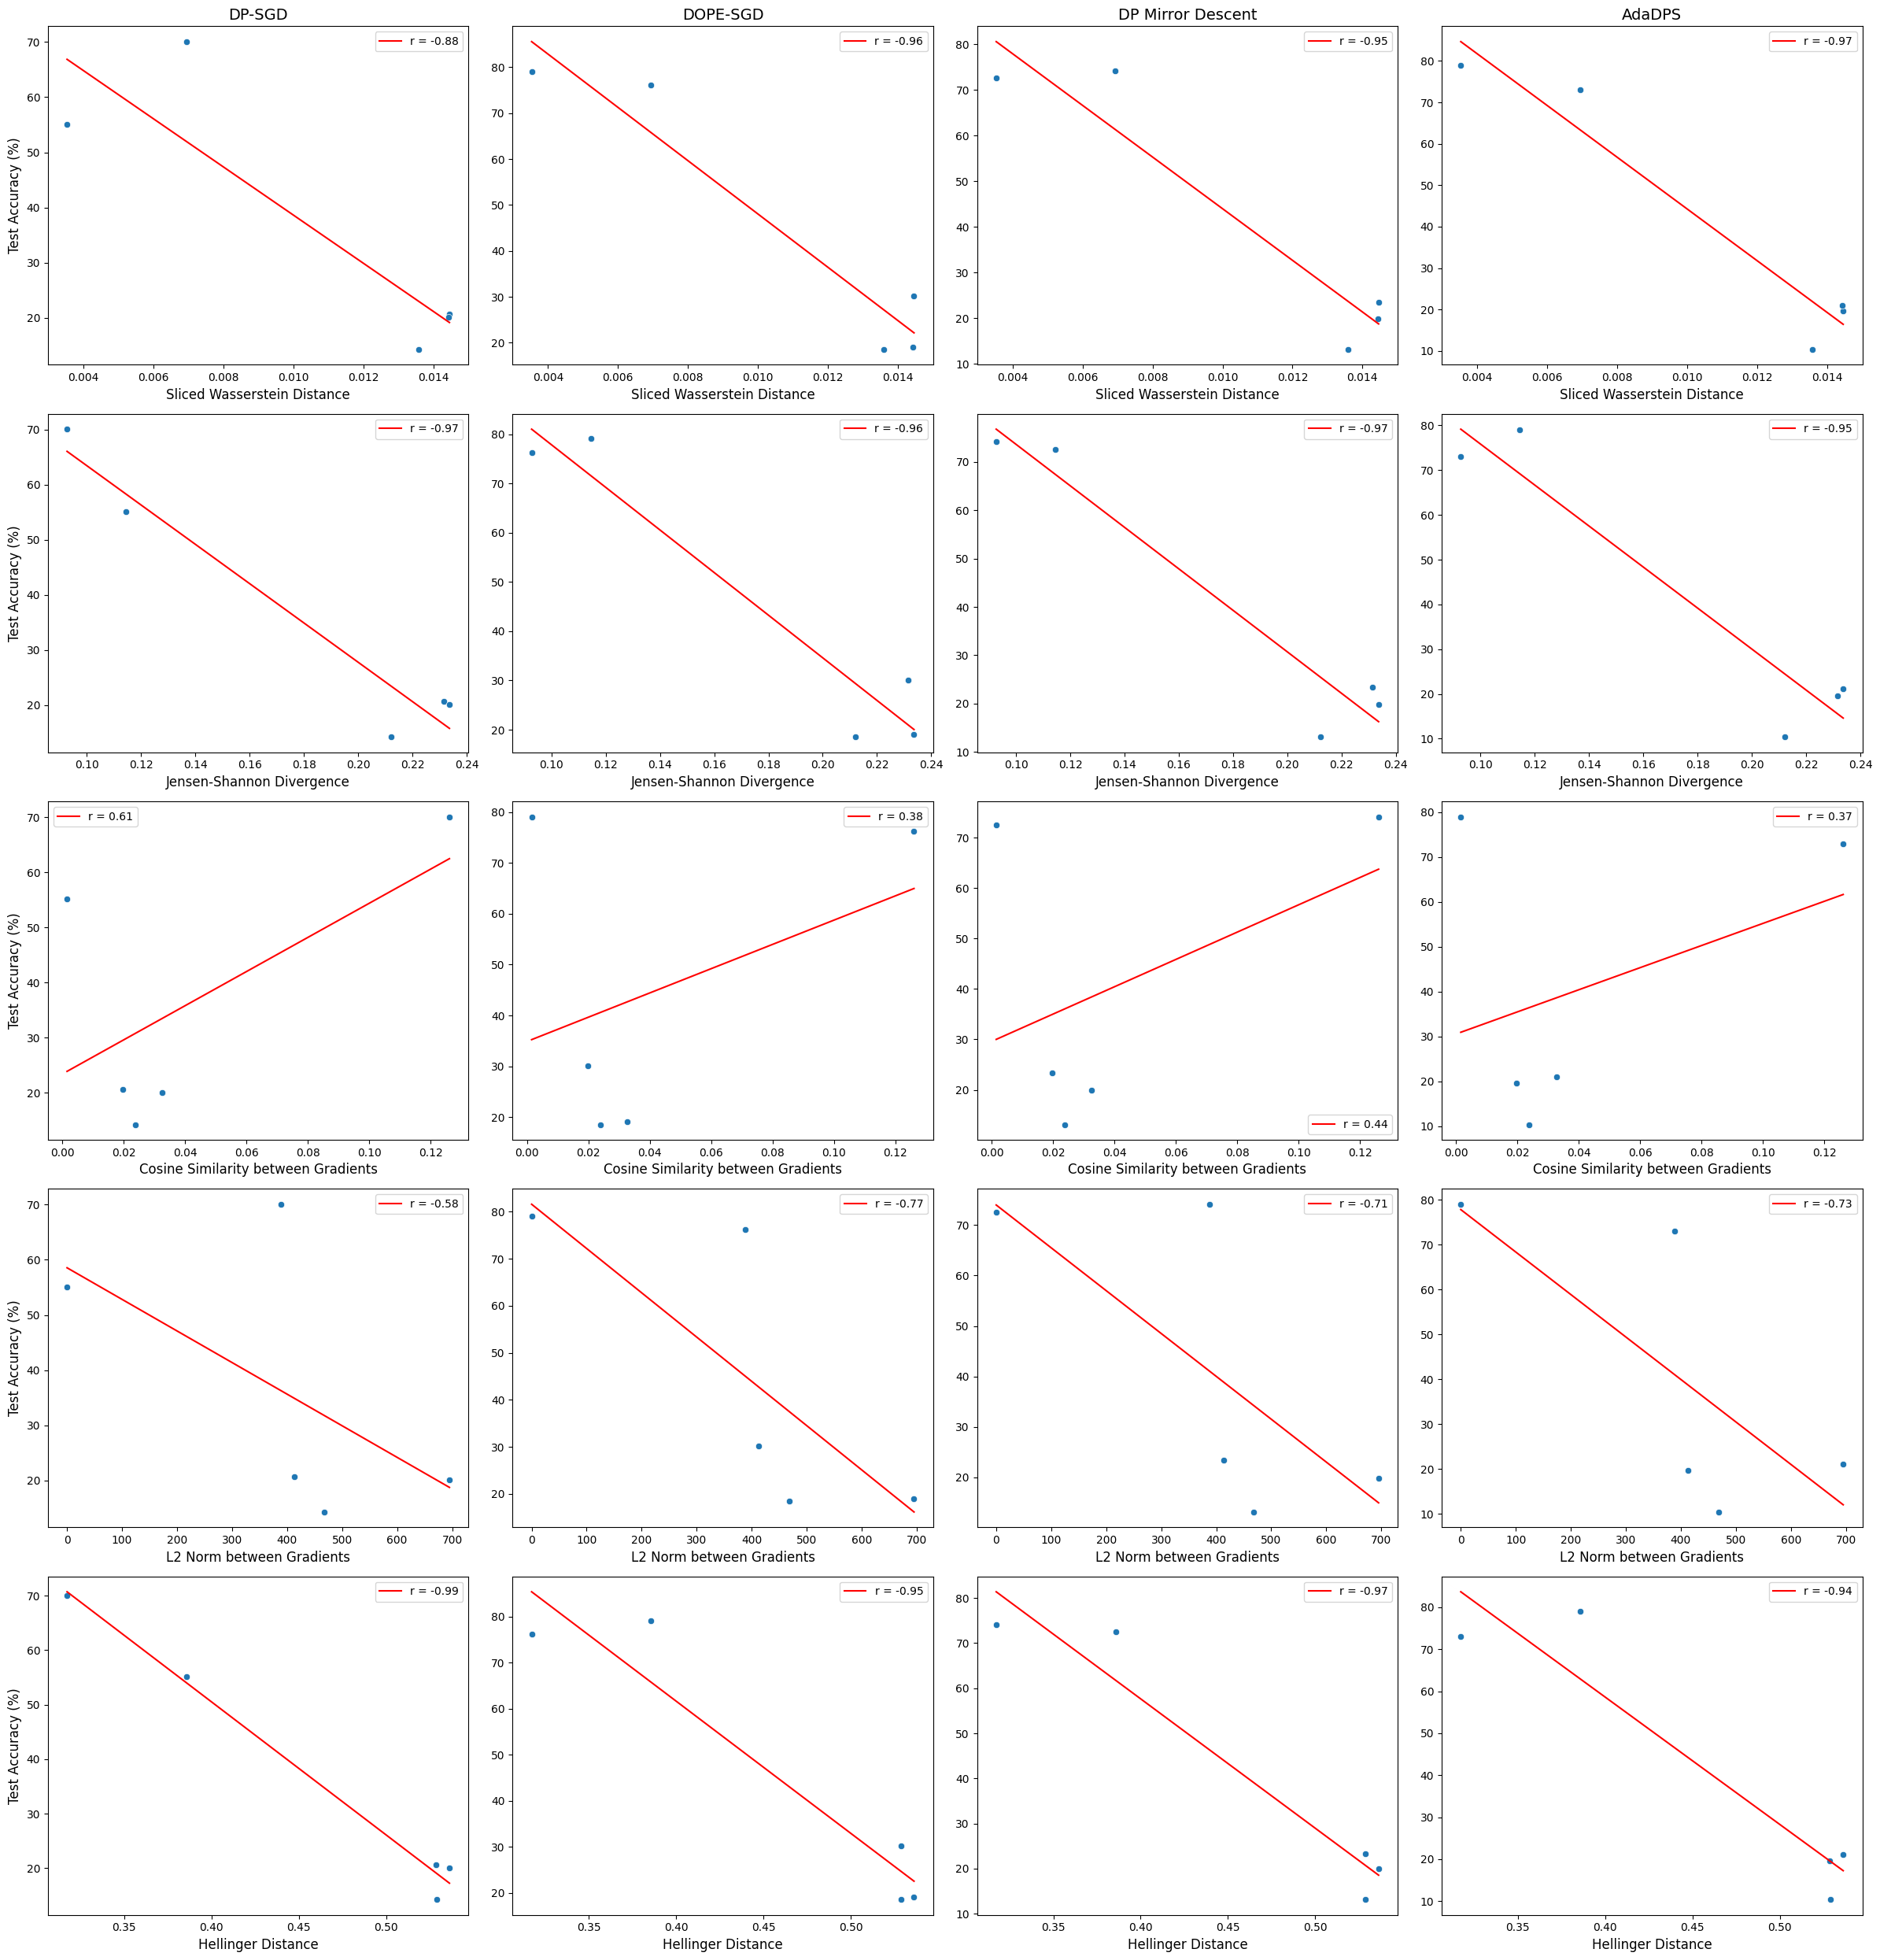

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

order = ["USPS", "FashionMNIST", "SVHN", "CIFAR-10", "STL-10"]

s_was_sim = [0.003530991563, 0.006940077492, 0.014461491775, 0.014432070567, 0.01358911509]
jsd_sim = [0.114499000000, 0.092713000000, 0.231467000000, 0.233652000000, 0.212181]
cosine_sim = [0.0015, 0.1261, 0.0197, 0.0326, 0.0238]
l2_norm_sim = [0.074, 388.1557, 413.0328, 695.0426, 468.1418]
#mmd_sim = [0.017933581000, 0.145852920000, 0.022628454000, 0.015758608000]
hellinger_sim = [0.385654985772, 0.317277278800, 0.528687696487, 0.536272981830, 0.528780144]
#fid_sim = [___, 229.598815917968, 190.478591918945, 235.153808593750, ___]

basic_dp_sgd = [55.11, 70.08, 20.68, 20.07, 14.26]
basic_dope_sgd = [79.12, 76.21, 30.13, 19.03, 18.54]
basic_mirror_descent = [72.55, 74.13, 23.38, 19.90, 13.14]
basic_ada_dps = [78.97, 72.98, 19.59, 21.07, 10.39]

all_algorithms = {
    "DP-SGD": basic_dp_sgd,
    "DOPE-SGD": basic_dope_sgd,
    "DP Mirror Descent": basic_mirror_descent,
    "AdaDPS": basic_ada_dps,
}

all_similarity_metrics = {
    "Sliced Wasserstein Distance": s_was_sim,
    "Jensen-Shannon Divergence": jsd_sim,
    "Cosine Similarity between Gradients": cosine_sim,
    "L2 Norm between Gradients": l2_norm_sim,
    #"Maximum Mean Discrepancy": mmd_sim,
    "Hellinger Distance": hellinger_sim,
    #"Frechet-Inception Distance": fid_sim
}

k = len(all_algorithms)
n = len(all_similarity_metrics)
fig, axes = plt.subplots(nrows=n, ncols=k, figsize=(6 * k, 5 * n), squeeze=False)

for row_idx, (sim_name, sim_values) in enumerate(all_similarity_metrics.items()):
    for col_idx, (algo_name, accuracies) in enumerate(all_algorithms.items()):
        ax = axes[row_idx][col_idx]

        # Scatter plot
        sns.scatterplot(x=sim_values, y=accuracies, ax=ax)

        # Fit line
        slope, intercept, r_value, _, _ = linregress(sim_values, accuracies)
        x_vals = sorted(sim_values)
        y_vals = [slope * x + intercept for x in x_vals]
        ax.plot(x_vals, y_vals, color='red', label=f'r = {r_value:.2f}')

        # Labeling
        if row_idx == 0:
            ax.set_title(f"{algo_name}", fontsize=14)
        if col_idx == 0:
            ax.set_ylabel("Test Accuracy (%)", fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xlabel(f"{sim_name}", fontsize=12)
        ax.legend()

plt.tight_layout()
plt.show()